In [1]:
from cubespecfit.fitting import fitcube
from cubespecfit.models import ha_nii_model

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from astropy.io import fits

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Read in the data cube, uncertainty cube, FITS header
This example requires that the data be contained in extension 1, with the uncertainties in extension 2. The file used here is the level 3 pipeline product
for SPT2147-50, and is included in this repository.

In [2]:
file = "jw01355-o019_t005_nirspec_g395m-f290lp_s3d.fits"
hdul = fits.open(file)

cube = hdul[1].data
err_cube = hdul[2].data
header = hdul[1].header

# Determine the wavelength axis from the FITS header, set the systemic redshift
The redshift is used in determining which region of the cube contains the relevant emission lines. It does not have to be overly precise.

In [3]:
wl = np.linspace(header["CRVAL3"], header["CRVAL3"]+(header["NAXIS3"]-1)*header["CDELT3"], header["NAXIS3"])
z_sys = 3.760

# Set the model to be fit to the data, and define the parameter settings
This example uses the H-alpha+[NII] triple-Gaussian model. The parameters are:
- Redshift
- H-alpha integrated line flux
- Line RMS
- [NII]/H-alpha ratio
- Continuum flux

Parameters are supplied as a dictionary, where each entry gives an initial `value` and optional `min`/`max` bounds
(and optionally `vary` or `expr`). The wavelengths of the lines are fixed, and their linewidths are tied to be the
same (a simplistic example).

The model also takes a spectral resolution `R`, which is an instrument setting rather than something to fit. It has a
default, so it does not need to appear here — it is held fixed automatically. To fit at a different resolution, add
e.g. `'R': {'value': 2700, 'vary': False}`.

Note that the fitting code normalizes each spectrum by its maximum value, so the peak line flux of the model should
be approximately 1.


In [4]:
model = ha_nii_model

sig_kms_to_um = lambda v: v / 2.35 / 3e05 * ((1 + z_sys) * 0.65646)

params_dict = {
    'z':     {'value': z_sys,      'min': z_sys - 0.004,   'max': z_sys + 0.004},
    'I_Ha':  {'value': 0.005,      'min': 0.0005,          'max': 0.1},
    'sig':   {'value': sig_kms_to_um(300), 'min': sig_kms_to_um(100), 'max': sig_kms_to_um(1000)},
    'NIIHa': {'value': 0.2,        'min': 0.0,             'max': 3.0},
    'c':     {'value': 0.5,        'min': 0.1,             'max': 1.0},
}

constraints = None   # see fitspec_lmfit docstring for inequality constraints


# Choose wavelength range to fit, S/N threshold for the fitting, minimum and maximum bin size
Here we use a central wavelength of 0.65646$\mu$m, i.e. H-alpha in vacuum, and fit within a region of $\pm$0.1$\mu$m. For the continuum estimate we
mask the region that is +0.02/-0.01$\mu$m of the central wavelength.
These numbers were chosen through trial and error, and the grid plots that are output after the fitting is complete show the fitting region, and 
highlight the no_line region so that the user can visually assess their decision.
A S/N of 5 is chosen to ensure that only real signal is detected (in reality the code is not perfect and sometimes it finds fits where there appears
to be no real emission - this is a work in progress), and we set 
minimum and maximum bin sizes of 1 and 3. If the detections are strong enough, these can both be set to 0.

In [5]:
l0 = 0.65646
dl = 0.1
l = l0*(1+z_sys)
no_line = (wl < l-0.01) | (wl > l+0.02)

snr_cut = 5
bin_lower, bin_upper = 1, 3

# Do the fitting

In [6]:
param_cube, param_err_cube, snr_map, bin_map, norm_map = fitcube(
    cube=cube, err_cube=err_cube, wl=wl, z_sys=z_sys, model=model,
    params_dict=params_dict, constraints=constraints, l0=l0, no_line=no_line, dl=dl,
    snr_cut=snr_cut, bin_lower=bin_lower, bin_upper=bin_upper, save_grid=True)

param_cube[param_cube == 0], param_err_cube[param_err_cube == 0] = np.nan, np.nan   # unfitted pixels -> NaN
param_cube[0, :, :] = ((1 + param_cube[0, :, :]) - (1 + z_sys)) / (1 + z_sys) * 3e05  # redshift -> velocity
param_err_cube[0, :, :] = param_err_cube[0, :, :] / (1 + z_sys) * 3e05
param_cube[2, :, :] *= 3E05 / (l0 * (1 + z_sys))                                      # sigma -> velocity
param_err_cube[2, :, :] *= 3E05 / (l0 * (1 + z_sys))


Fitting...


  0%|          | 0/47 [00:00<?, ?it/s]

  2%|▏         | 1/47 [00:00<00:16,  2.83it/s]

  4%|▍         | 2/47 [00:01<00:28,  1.60it/s]

  6%|▋         | 3/47 [00:02<00:33,  1.30it/s]

...

 96%|█████████▌| 45/47 [00:57<00:01,  1.34it/s]

 98%|█████████▊| 46/47 [00:57<00:00,  1.46it/s]

100%|██████████| 47/47 [00:57<00:00,  1.75it/s]

100%|██████████| 47/47 [00:57<00:00,  1.23s/it]

Done.


# Quick plots to visually assess the output

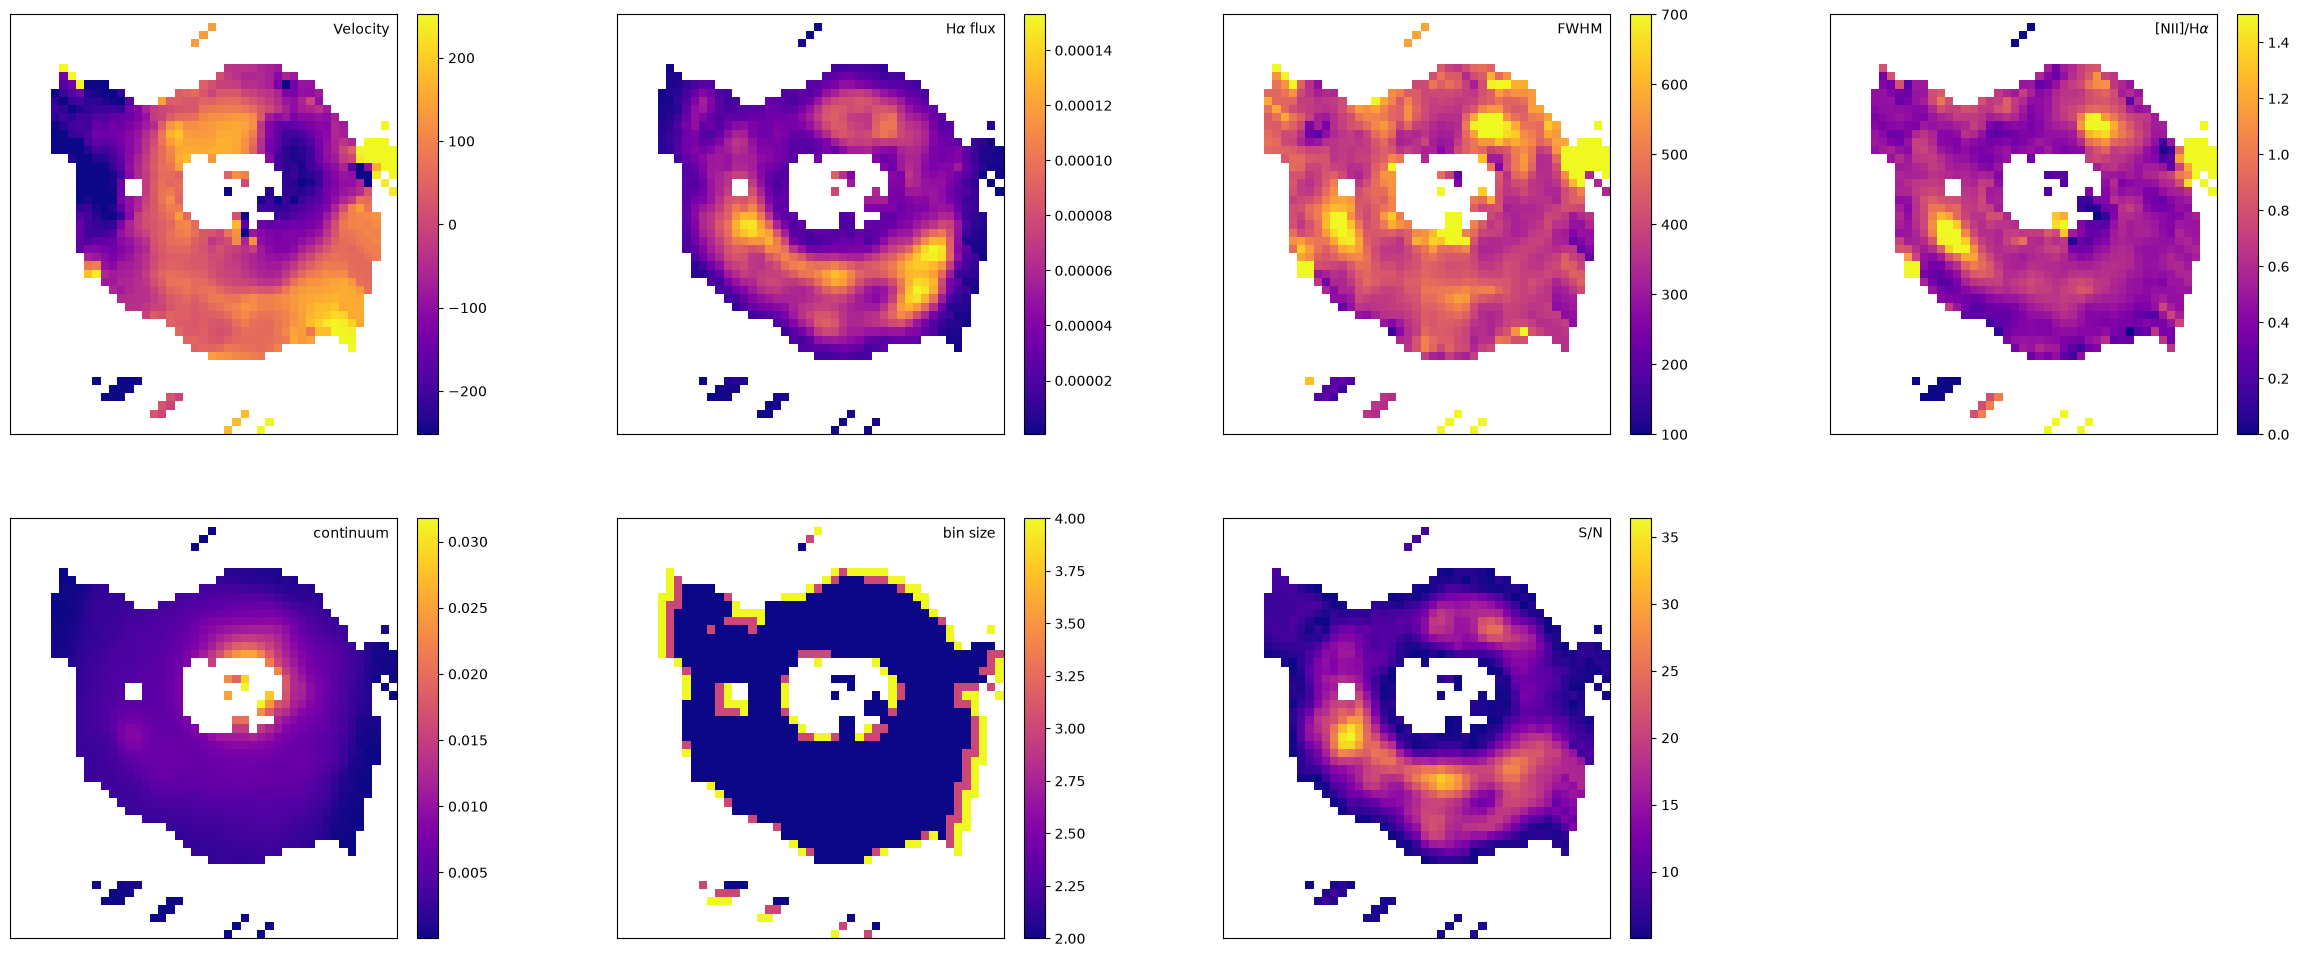

In [7]:
fig = plt.figure(figsize=(30,12))
gs = gridspec.GridSpec(2,4)

# velocity map
ax0 = plt.subplot(gs[0])
im = ax0.imshow(param_cube[0], cmap="plasma")#, vmin=-100, vmax=100)
plt.colorbar(im, fraction=0.046, pad=0.04)
# H-alpha integrated flux map
ax1 = plt.subplot(gs[1])
im = ax1.imshow(param_cube[1]*norm_map, cmap="plasma")
plt.colorbar(im, fraction=0.046, pad=0.04)
# FWHM map
ax2 = plt.subplot(gs[2])
im = ax2.imshow(param_cube[2]*2.35, cmap="plasma", vmin=100, vmax=700)
plt.colorbar(im, fraction=0.046, pad=0.04)
# [NII]/H-alpha map
ax3 = plt.subplot(gs[3])
im = ax3.imshow(param_cube[3], cmap="plasma", vmin=0, vmax=1.5)
plt.colorbar(im, fraction=0.046, pad=0.04)
# continuum map
ax4 = plt.subplot(gs[4])
im = ax4.imshow(param_cube[4]*norm_map, cmap="plasma")
plt.colorbar(im, fraction=0.046, pad=0.04)
# bin size map
ax5 = plt.subplot(gs[5])
im = ax5.imshow(bin_map, cmap="plasma")
plt.colorbar(im, fraction=0.046, pad=0.04)
# S/N map
ax6 = plt.subplot(gs[6])
im = ax6.imshow(snr_map, cmap="plasma")
plt.colorbar(im, fraction=0.046, pad=0.04)

labels = ["Velocity", r"H$\alpha$ flux", "FWHM", r"[NII]/H$\alpha$",
          "continuum", "bin size", "S/N"]
for i, ax in enumerate([ax0,ax1,ax2,ax3,ax4,ax5,ax6]):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.98, 0.98, labels[i], ha="right", va="top", transform=ax.transAxes, c="k")

plt.show()